# Experiment No. 2

## Title
**To implement Bresenham’s Line Drawing Algorithm for drawing a straight line between two points**

## Objective
To generate a straight line between two given points using Bresenham’s algorithm and observe efficient pixel plotting without floating-point calculations.

## Theory
Bresenham’s Line Drawing Algorithm is an efficient method for drawing a straight line using only integer calculations. It avoids floating-point operations, making it faster than the DDA algorithm.

For a line between $(x_1, y_1)$ and $(x_2, y_2)$:

$$
dx = x_2 - x_1
$$

$$
dy = y_2 - y_1
$$

The algorithm uses a decision parameter:

$$
p = 2dy - dx
$$

At each step:
- If $p < 0$, the next point is $(x+1, y)$  
- If $p \geq 0$, the next point is $(x+1, y+1)$ and update $p$

The decision parameter is updated incrementally to determine the next pixel position. This method ensures accurate and efficient line generation on raster displays.

## Procedure
1. Input the starting point $(x_0, y_0)$ and ending point $(x_1, y_1)$.
2. Calculate $dx$ and $dy$.
3. Initialize the decision parameter $p = 2dy - dx$.
4. Set the initial point $(x, y) = (x_0, y_0)$.
5. Plot the initial point.
6. For each step:
   - Increment $x$ by 1.
   - If $p < 0$, update $p = p + 2dy$.
   - Else:
     - Increment $y$ by 1.
     - Update $p = p + 2dy - 2dx$.
7. Repeat until the end point is reached.
8. Plot all generated points and display coordinates.

## Output
- A straight line drawn between the given two points
- Generated coordinate points in the format:
  `[(x1, y1), (x2, y2), ...]`
- Output image saved as `Exp2_Output.png`

## Result and Discussion
The Bresenham algorithm successfully generated a straight line using only integer arithmetic. The plotted points form a continuous line with high accuracy. Compared to DDA, this method is more efficient as it avoids floating-point calculations and reduces computational cost.

Generated Coordinates: [(10, 15), (11, 16), (11, 17), (12, 18), (13, 19), (13, 20), (14, 21), (15, 22), (15, 23), (16, 24), (17, 25), (17, 26), (18, 27), (19, 28), (19, 29), (20, 30)]


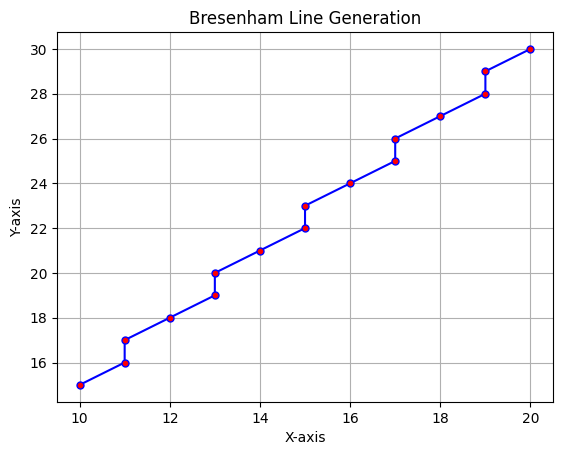

In [4]:
from matplotlib import pyplot as plt

def bresenham(x0, y0, x1, y1):
    x_coordinates = []
    y_coordinates = []

    dx = abs(x1 - x0)
    dy = abs(y1 - y0)

    x, y = x0, y0

    sx = 1 if x1 > x0 else -1
    sy = 1 if y1 > y0 else -1

    if dx > dy:
        p = 2 * dy - dx
        for i in range(dx + 1):
            x_coordinates.append(x)
            y_coordinates.append(y)

            x += sx
            if p < 0:
                p += 2 * dy
            else:
                y += sy
                p += 2 * (dy - dx)
    else:
        p = 2 * dx - dy
        for i in range(dy + 1):
            x_coordinates.append(x)
            y_coordinates.append(y)

            y += sy
            if p < 0:
                p += 2 * dx
            else:
                x += sx
                p += 2 * (dx - dy)

    coordinates = list(zip(x_coordinates, y_coordinates))
    print("Generated Coordinates:", coordinates)

    plt.plot(
        x_coordinates,
        y_coordinates,
        color="blue",
        marker="o",
        markersize=5,
        markerfacecolor="red"
    )
    plt.title("Bresenham Line Generation")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.savefig("Exp2_Output.png")
    plt.show()


# Example
bresenham(10, 15, 20, 30)